

# Canonical Correlation Analysis (CCA) in SSVEP

## 1. Overview
**Canonical Correlation Analysis (CCA)** is a multivariate statistical method used to measure the linear relationship between two sets of multidimensional variables. In EEG-based **Steady-State Visual Evoked Potential (SSVEP)** systems, it is the standard algorithm used to identify which stimulus frequency a subject is focusing on by comparing live EEG signals against artificial reference signals.



---

## 2. Problem Formulation
Let:
* $X \in \mathbb{R}^{n \times m}$: EEG data ($n$ samples, $m$ channels).
* $Y \in \mathbb{R}^{n \times p}$: Reference signal matrix (sine/cosine components).

CCA seeks to find projection vectors $w_x \in \mathbb{R}^{m}$ and $w_y \in \mathbb{R}^{p}$ such that the correlation between the linear combinations $u = X w_x$ and $v = Y w_y$ is maximized.

---

## 3. Objective Function
The canonical correlation coefficient $\rho$ is defined as:

$$\rho = \max_{w_x, w_y} \frac{E[w_x^T X^T Y w_y]}{\sqrt{E[w_x^T X^T X w_x] E[w_y^T Y^T Y w_y]}}$$

---

## 4. Optimization Formulation
CCA can be expressed as a constrained optimization problem:

$$\max_{w_x, w_y} w_x^T \Sigma_{XY} w_y$$

**Subject to:**
$$w_x^T \Sigma_{XX} w_x = 1, \quad w_y^T \Sigma_{YY} w_y = 1$$

Where:
* $\Sigma_{XX}$ and $\Sigma_{YY}$: Auto-covariance matrices of $X$ and $Y$.
* $\Sigma_{XY}$: Cross-covariance matrix between $X$ and $Y$.

---

## 5. Eigenvalue Solution
The optimization problem is solved by finding the eigenvalues of the following matrix:

$$\Sigma_{XX}^{-1} \Sigma_{XY} \Sigma_{YY}^{-1} \Sigma_{YX} w_x = \lambda w_x$$

The square root of the largest eigenvalue, $\sqrt{\lambda}$, represents the maximum correlation coefficient $\rho$.

---

## 6. Application in SSVEP Detection
To identify the target frequency among a set of frequencies $\{f_1, f_2, \dots, f_k\}$:

1.  **Construct Reference Signals ($Y_k$):** For each frequency, generate a reference matrix consisting of sine and cosine waves, typically including harmonics:
    $$Y_k = \begin{bmatrix} \sin(2\pi f_k t) \\ \cos(2\pi f_k t) \\ \vdots \\ \cos(2\pi H f_k t) \end{bmatrix}^T$$
2.  **Compute CCA:** Calculate the maximum correlation $\rho_k$ between the EEG signal $X$ and each reference $Y_k$.
3.  **Classification:** The stimulus frequency with the highest correlation is selected:
    $$\hat{k} = \arg\max_k \rho_k$$

---

## 7. Intuition
CCA is highly effective for SSVEP because it:
* **Extracts Spatial Filters:** It automatically determines which EEG channels contain the strongest stimulus response, effectively "weighting" relevant occipital electrodes.
* **Is Phase-Independent:** Using both sine and cosine components allows the model to capture the brain's response regardless of the inherent phase lag (latency).
* **Optimizes Signal-to-Noise Ratio (SNR):** By projecting the data, it maximizes the underlying signal shared between the brain activity and the stimulus frequency.

---

## 8. Limitations & Common Improvements

### Limitations
* **Linearity:** It only captures linear relationships between the EEG and references.
* **Short Windows:** Accuracy drops significantly when the signal window is very short (e.g., $< 0.5$ seconds).
* **Spontaneous Activity:** High-amplitude background EEG noise can sometimes lead to false positives.

### Common Improvements
* **Filter Bank CCA (FBCCA):** Enhances detection by decomposing the EEG into multiple sub-bands to leverage harmonic information.
* **Task-Related Component Analysis (TRCA):** A supervised method that uses individual training data to improve SNR beyond standard CCA.
* **Ensemble CCA:** Combines standard CCA with individual calibration data for higher robustnes.

In [61]:
import sys
sys.path.append('..')
import glob
import importlib
import sys




import numpy as np
from scipy.io import loadmat
from scipy.signal import butter, filtfilt, detrend
import matplotlib.pyplot as plt

from src.config import FS, STIM_ONSET, CH_NAMES, TARGET_FREQS , WINDOW_SAMPLES

from src.CCA import  load_subject, preprocess_trial , generate_reference_signals , cca_score, predict_cca, evaluate_subject_cca

In [62]:
import importlib
import src.CCA
importlib.reload(src.CCA)
from src.CCA import evaluate_subject_cca

In [63]:
file = r"C:\Users\Luchitha\Documents\BCI\SSVEP\data\s1.mat"

In [64]:
eeg = load_subject(file)

print("EEG shape:", eeg.shape)

EEG shape: (12, 8, 1114, 15)


In [65]:
refs = generate_reference_signals(TARGET_FREQS, WINDOW_SAMPLES, FS)

In [66]:
# OPTIONAL: select occipital channels (UPDATE THIS!)
# Example: Oz, O1, O2 → indices depend on dataset
use_channels = None  

# Try with rejection threshold
accuracy = evaluate_subject_cca(
    eeg,
    use_channels=use_channels
    
)


accuracy


(0.5222222221932099,
 array([0.93333333, 0.46666667, 0.26666667, 1.        , 0.6       ,
        0.4       , 0.8       , 0.26666667, 0.26666667, 0.86666667,
        0.06666667, 0.33333333]),
 array([[14,  0,  0,  0,  0,  0,  1,  0,  0,  0,  0,  0],
        [ 2,  7,  0,  1,  2,  0,  1,  1,  0,  1,  0,  0],
        [ 0,  2,  4,  3,  1,  2,  2,  0,  0,  0,  1,  0],
        [ 0,  0,  0, 15,  0,  0,  0,  0,  0,  0,  0,  0],
        [ 1,  0,  0,  1,  9,  0,  3,  0,  0,  1,  0,  0],
        [ 4,  0,  0,  0,  1,  6,  1,  0,  0,  2,  1,  0],
        [ 0,  0,  0,  2,  0,  0, 12,  0,  0,  1,  0,  0],
        [ 2,  1,  0,  4,  0,  0,  0,  4,  0,  3,  1,  0],
        [ 2,  0,  0,  0,  1,  0,  4,  0,  4,  1,  0,  3],
        [ 0,  0,  0,  1,  0,  0,  1,  0,  0, 13,  0,  0],
        [ 2,  0,  0,  5,  1,  0,  4,  0,  0,  2,  1,  0],
        [ 3,  1,  0,  3,  0,  0,  3,  0,  0,  0,  0,  5]]))

In [67]:


filepaths = sorted(glob.glob("../data/*.mat"))  # change path

all_confusions = []
all_per_class = []

for path in filepaths:
    eeg = load_subject(path)

    acc, per_class_acc, confusion = evaluate_subject_cca(
        eeg,
        use_channels=use_channels
    )

    print(f"{path} → Accuracy: {acc:.3f}")

    all_confusions.append(confusion)
    all_per_class.append(per_class_acc)

all_confusions = np.array(all_confusions)  # (subjects, C, C)
all_per_class = np.array(all_per_class)


../data\s1.mat → Accuracy: 0.522
../data\s10.mat → Accuracy: 0.828
../data\s2.mat → Accuracy: 0.539
../data\s3.mat → Accuracy: 0.850
../data\s4.mat → Accuracy: 0.967
../data\s5.mat → Accuracy: 0.917
../data\s6.mat → Accuracy: 0.983
../data\s7.mat → Accuracy: 0.917
../data\s8.mat → Accuracy: 0.994
../data\s9.mat → Accuracy: 0.889


In [68]:
mean_per_class = np.mean(all_per_class, axis=0)
std_per_class = np.std(all_per_class, axis=0)


In [69]:
mean_confusion = np.mean(all_confusions, axis=0)
norm_confusion = mean_confusion / (mean_confusion.sum(axis=1, keepdims=True) + 1e-8)


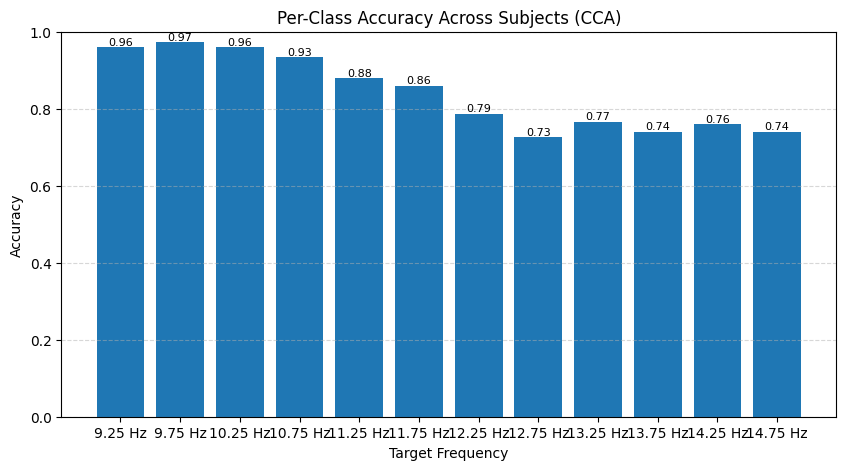

In [70]:

TARGET_FREQS = np.array(TARGET_FREQS)
mean_per_class = np.array(mean_per_class)
std_per_class = np.array(std_per_class)

# Sort by frequency
sorted_idx = np.argsort(TARGET_FREQS)

TARGET_FREQS_sorted = TARGET_FREQS[sorted_idx]
mean_sorted = mean_per_class[sorted_idx]
std_sorted = std_per_class[sorted_idx]

# Plot
plt.figure(figsize=(10, 5))

x = np.arange(len(TARGET_FREQS_sorted))

bars = plt.bar(x, mean_sorted, capsize=5)

plt.xticks(x, [f"{f:.2f} Hz" for f in TARGET_FREQS_sorted])
plt.xlabel("Target Frequency")
plt.ylabel("Accuracy")
plt.title("Per-Class Accuracy Across Subjects (CCA)")

plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Add value labels on top of bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.2f}",
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.show()



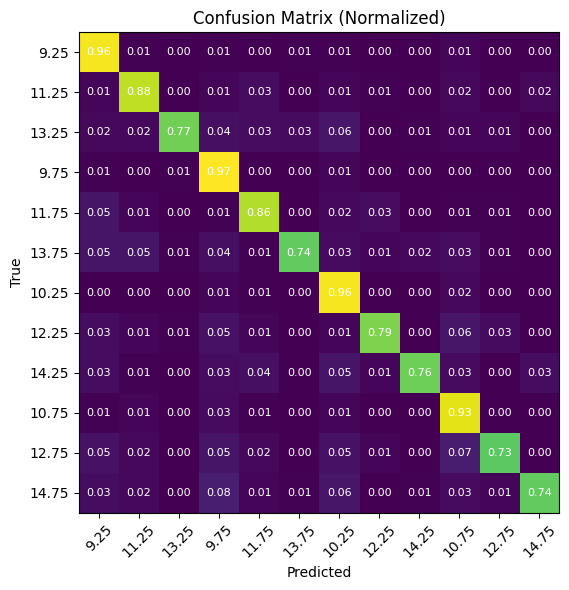

In [71]:
# Ensure arrays
TARGET_FREQS = np.array(TARGET_FREQS)

# Sort indices
sorted_idx = np.argsort(TARGET_FREQS)

# Reorder everything consistently
TARGET_FREQS_sorted = TARGET_FREQS[sorted_idx]
norm_confusion_sorted = norm_confusion[sorted_idx][:, sorted_idx]


plt.figure(figsize=(8, 6))
plt.imshow(norm_confusion, cmap='viridis')

for i in range(norm_confusion.shape[0]):
    for j in range(norm_confusion.shape[1]):
        plt.text(j, i, f"{norm_confusion[i, j]:.2f}",
                 ha='center', va='center', color='white', fontsize=8)

plt.xticks(range(len(TARGET_FREQS)), [f"{f:.2f}" for f in TARGET_FREQS], rotation=45)
plt.yticks(range(len(TARGET_FREQS)), [f"{f:.2f}" for f in TARGET_FREQS])

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Normalized)")

plt.tight_layout()
plt.show()


In [72]:
use_channels = ["POz", "PO4",  "O1", "Oz", "O2"]

acc = evaluate_subject_cca(eeg, use_channels=use_channels)



In [73]:


filepaths = sorted(glob.glob("../data/*.mat"))  # change path

all_confusions = []
all_per_class = []

for path in filepaths:
    eeg = load_subject(path)

    acc, per_class_acc, confusion = evaluate_subject_cca(
        eeg,
        use_channels=use_channels
    )

    print(f"{path} → Accuracy: {acc:.3f}")

    all_confusions.append(confusion)
    all_per_class.append(per_class_acc)

all_confusions = np.array(all_confusions)  # (subjects, C, C)
all_per_class = np.array(all_per_class)


../data\s1.mat → Accuracy: 0.394
../data\s10.mat → Accuracy: 0.644
../data\s2.mat → Accuracy: 0.467
../data\s3.mat → Accuracy: 0.678
../data\s4.mat → Accuracy: 0.967
../data\s5.mat → Accuracy: 0.806
../data\s6.mat → Accuracy: 0.883
../data\s7.mat → Accuracy: 0.283
../data\s8.mat → Accuracy: 1.000
../data\s9.mat → Accuracy: 0.856


In [74]:
mean_per_class = np.mean(all_per_class, axis=0)
std_per_class = np.std(all_per_class, axis=0)

mean_confusion = np.mean(all_confusions, axis=0)
norm_confusion = mean_confusion / (mean_confusion.sum(axis=1, keepdims=True) + 1e-8)


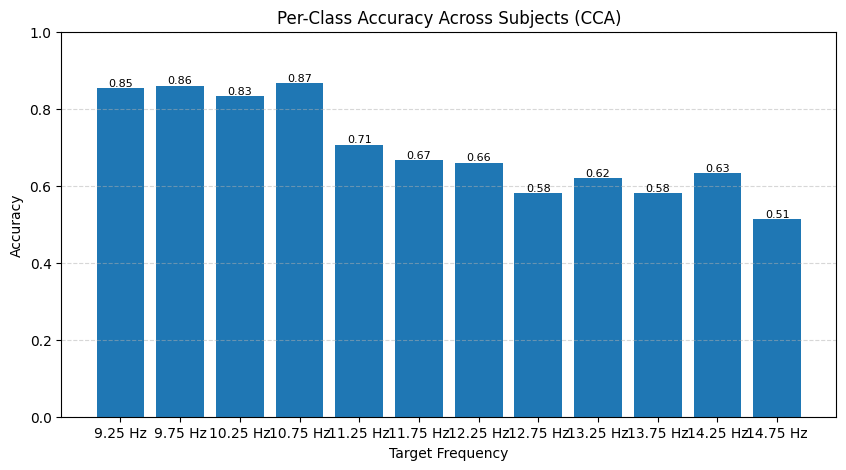

In [75]:

TARGET_FREQS = np.array(TARGET_FREQS)
mean_per_class = np.array(mean_per_class)
std_per_class = np.array(std_per_class)

# Sort by frequency
sorted_idx = np.argsort(TARGET_FREQS)

TARGET_FREQS_sorted = TARGET_FREQS[sorted_idx]
mean_sorted = mean_per_class[sorted_idx]
std_sorted = std_per_class[sorted_idx]

# Plot
plt.figure(figsize=(10, 5))

x = np.arange(len(TARGET_FREQS_sorted))

bars = plt.bar(x, mean_sorted, capsize=5)

plt.xticks(x, [f"{f:.2f} Hz" for f in TARGET_FREQS_sorted])
plt.xlabel("Target Frequency")
plt.ylabel("Accuracy")
plt.title("Per-Class Accuracy Across Subjects (CCA)")

plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Add value labels on top of bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.2f}",
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.show()



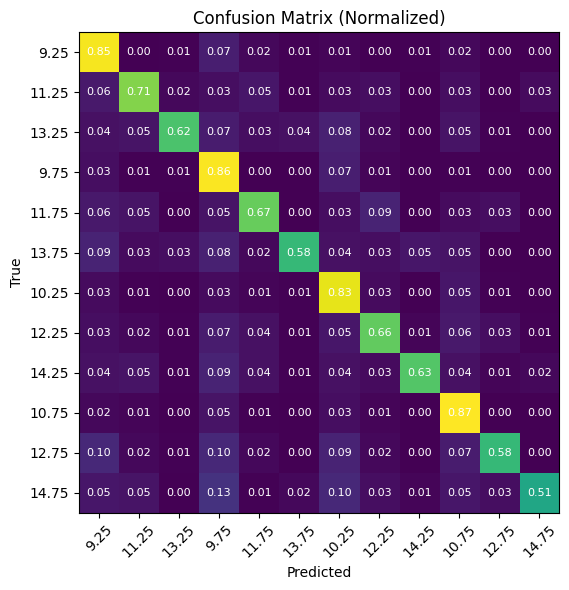

In [76]:
# Ensure arrays
TARGET_FREQS = np.array(TARGET_FREQS)

# Sort indices
sorted_idx = np.argsort(TARGET_FREQS)

# Reorder everything consistently
TARGET_FREQS_sorted = TARGET_FREQS[sorted_idx]
norm_confusion_sorted = norm_confusion[sorted_idx][:, sorted_idx]


plt.figure(figsize=(8, 6))
plt.imshow(norm_confusion, cmap='viridis')

for i in range(norm_confusion.shape[0]):
    for j in range(norm_confusion.shape[1]):
        plt.text(j, i, f"{norm_confusion[i, j]:.2f}",
                 ha='center', va='center', color='white', fontsize=8)

plt.xticks(range(len(TARGET_FREQS)), [f"{f:.2f}" for f in TARGET_FREQS], rotation=45)
plt.yticks(range(len(TARGET_FREQS)), [f"{f:.2f}" for f in TARGET_FREQS])

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Normalized)")

plt.tight_layout()
plt.show()
